In [50]:
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim  

Train size: 96
Validation size: 24
Test size: 32
Class distribution in training set: [12 12 12 12 12 12 12 12]
Class weights: [1. 1. 1. 1. 1. 1. 1. 1.]
Training neural network...
Train size: 96
Validation size: 24
Test size: 32
Epoch 1/500: Train Loss = 3.8889, Val Loss = 2.1679, Train Acc = 0.1458, Val Acc = 0.1250
Epoch 20/500: Train Loss = 3.0067, Val Loss = 2.1431, Train Acc = 0.2292, Val Acc = 0.2500
Epoch 40/500: Train Loss = 2.8208, Val Loss = 2.1021, Train Acc = 0.3125, Val Acc = 0.2083
Epoch 60/500: Train Loss = 2.3592, Val Loss = 2.0806, Train Acc = 0.4167, Val Acc = 0.2083
Epoch 80/500: Train Loss = 2.2447, Val Loss = 2.0496, Train Acc = 0.5312, Val Acc = 0.2500
Epoch 100/500: Train Loss = 2.1972, Val Loss = 2.0452, Train Acc = 0.6042, Val Acc = 0.2500
Epoch 120/500: Train Loss = 2.0569, Val Loss = 2.0042, Train Acc = 0.6875, Val Acc = 0.2083
Epoch 140/500: Train Loss = 1.8580, Val Loss = 1.9923, Train Acc = 0.7292, Val Acc = 0.2083
Epoch 160/500: Train Loss = 1.8413, Val Lo

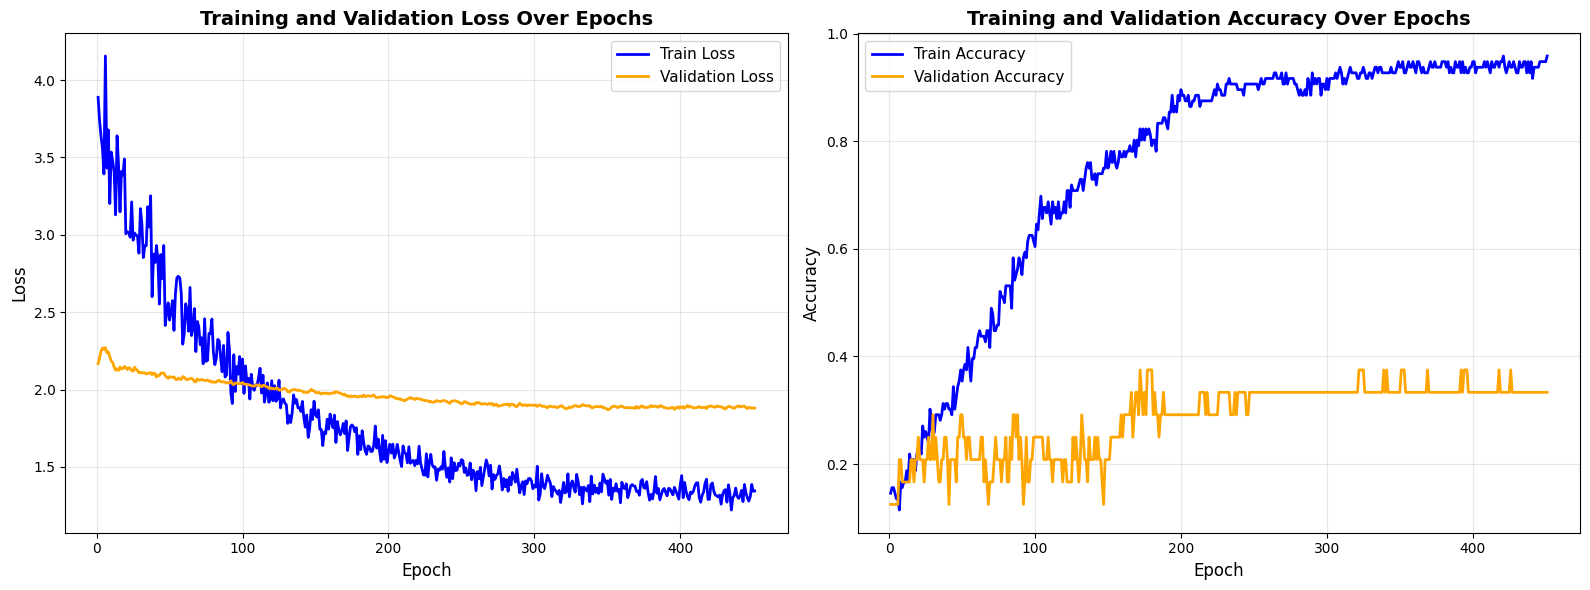


Final Test Accuracy: 0.4375
Number of epochs trained: 451

Comparison with Original Model:
Original Model Test Accuracy: 0.3438 (34.38%)
Improved Model Test Accuracy: 0.4375 (43.75%)
Absolute Improvement: +9.37 percentage points

Per-Class Performance Summary:
Anger       :  4 samples, Recall = 1.000
Contempt    :  4 samples, Recall = 0.000
Disgust     :  4 samples, Recall = 0.500
Fear        :  4 samples, Recall = 0.250
Happy       :  4 samples, Recall = 1.000
Neutral     :  4 samples, Recall = 0.250
Sad         :  4 samples, Recall = 0.250
Surprised   :  4 samples, Recall = 0.250


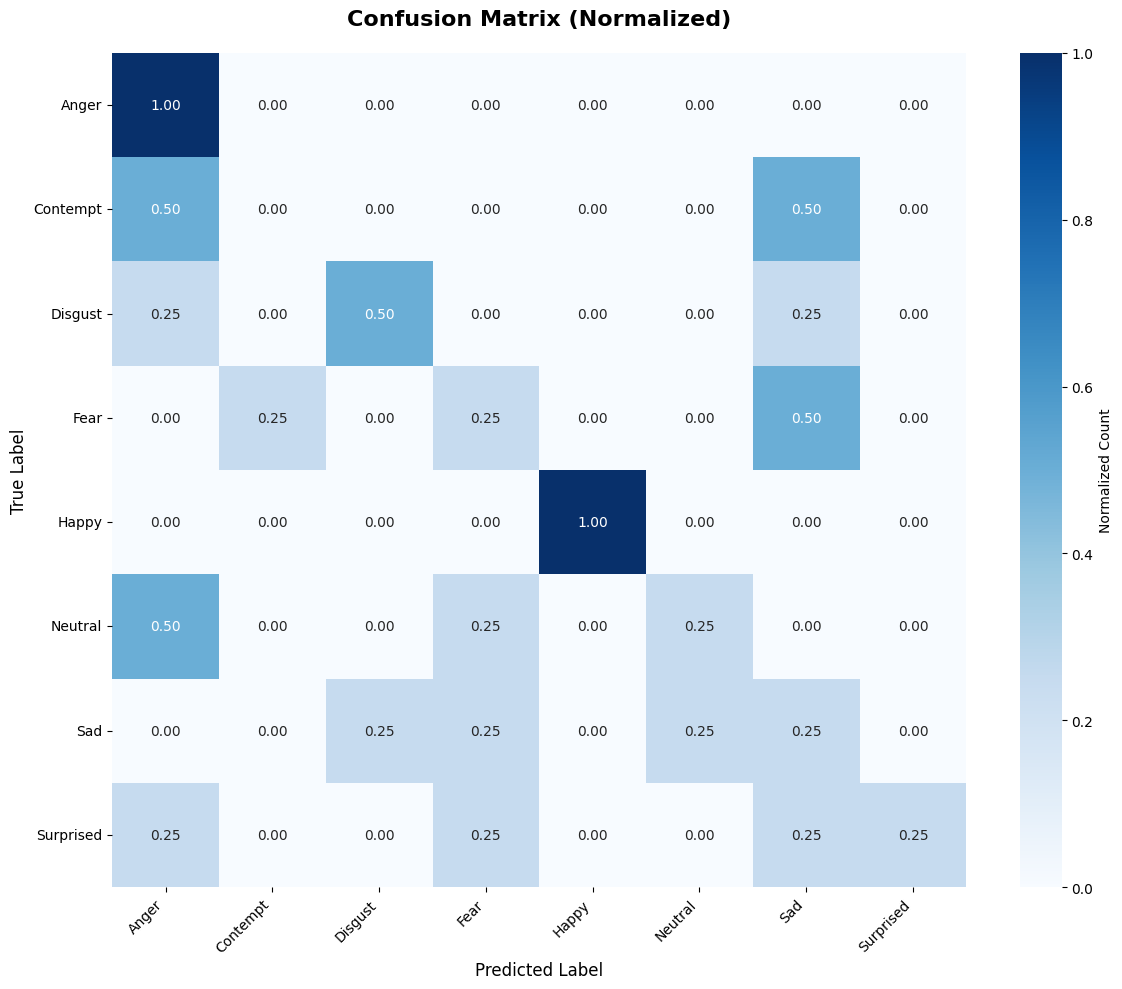

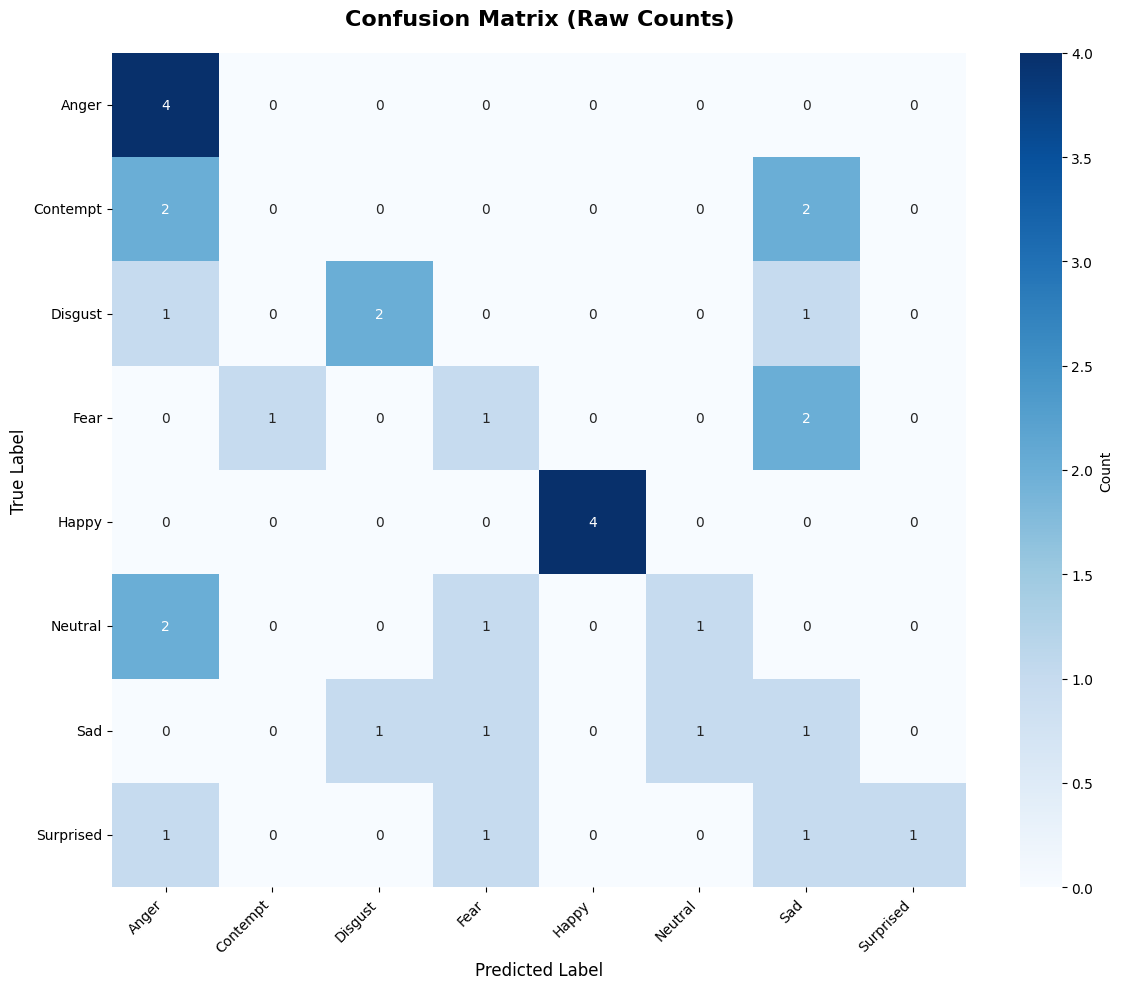


Key Improvements:
1. Added BatchNorm1d layers for training stability
2. Improved weight initialization (Kaiming/He)
3. Class-weighted loss function to handle imbalance
4. Mini-batch training with shuffling
5. Learning rate scheduling (ReduceLROnPlateau)
6. Early stopping with validation monitoring
7. Larger network (128->64->32) with tuned dropout (0.3)


In [51]:
from train_test_split import load_grouped_splits
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define PyTorch neural network
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes=(64, 32), num_classes=8, dropout=0.5, use_batchnorm=True):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
        
        # Weight initialization
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)

# Load and preprocess data
pca = PCA(n_components=0.90)
data = load_grouped_splits()
X_train, y_train, X_val, y_val, X_test, y_test, classes = data

X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_pca)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val_pca)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test_pca)
y_test_tensor = torch.LongTensor(y_test)

# Initialize model
input_size = X_train_pca.shape[1]
num_classes = len(classes)
model = MLP(input_size, hidden_sizes=(128, 64, 32), num_classes=num_classes, dropout=0.4, use_batchnorm=True)

# Compute class weights for imbalanced dataset
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes  # Normalize
class_weights_tensor = torch.FloatTensor(class_weights)

print(f"Class distribution in training set: {class_counts}")
print(f"Class weights: {class_weights}")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-2)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.4, patience=15)

# Training configuration
n_epochs = 500
batch_size = 16
patience = 100
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

# Track metrics over epochs
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Training neural network...")
print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

for epoch in range(n_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0
    
    # Mini-batch training
    indices = np.arange(len(X_train_tensor))
    np.random.shuffle(indices)
    
    for i in range(0, len(X_train_tensor), batch_size):
        batch_indices = indices[i:i+batch_size]
        batch_X = X_train_tensor[batch_indices]
        batch_y = y_train_tensor[batch_indices]
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_train_loss += loss.item() * len(batch_indices)
    
    epoch_train_loss /= len(X_train_tensor)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        
        train_pred = model(X_train_tensor).argmax(dim=1).numpy()
        val_pred = val_outputs.argmax(dim=1).numpy()
    
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    
    # Store metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs}: Train Loss = {epoch_train_loss:.4f}, Val Loss = {val_loss:.4f}, "
              f"Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBest validation loss: {best_val_loss:.4f}")

# Load best model for final evaluation
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model based on validation loss")

# Final predictions on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    y_pred = test_outputs.argmax(dim=1).numpy()

print("\n" + "="*50)
print("Final Test Results:")
print("="*50)
print(classification_report(y_test, y_pred, target_names=classes))

# Plot training and validation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot losses
epochs_range = range(1, len(train_losses) + 1)
ax1.plot(epochs_range, train_losses, label='Train Loss', linewidth=2, color='blue')
ax1.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2, color='orange')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot accuracies
ax2.plot(epochs_range, train_accuracies, label='Train Accuracy', linewidth=2, color='blue')
ax2.plot(epochs_range, val_accuracies, label='Validation Accuracy', linewidth=2, color='orange')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Get test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Number of epochs trained: {len(train_losses)}")

# Compare with baseline
print("\n" + "="*50)
print("Comparison with Original Model:")
print("="*50)
print("Original Model Test Accuracy: 0.3438 (34.38%)")
print(f"Improved Model Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
improvement = (test_accuracy - 0.3438) * 100
print(f"Absolute Improvement: {improvement:+.2f} percentage points")

# Per-class analysis
print("\n" + "="*50)
print("Per-Class Performance Summary:")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
for i, class_name in enumerate(classes):
    class_recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f"{class_name:12s}: {cm[i].sum():2d} samples, Recall = {class_recall:.3f}")

# Plot confusion matrix
plt.figure(figsize=(12, 10))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, cbar_kws={'label': 'Normalized Count'})
plt.title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Also plot raw counts
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Raw Counts)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
